In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# Load Mathematica-style text files
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

Fit slope = 0.475, intercept = -1.775


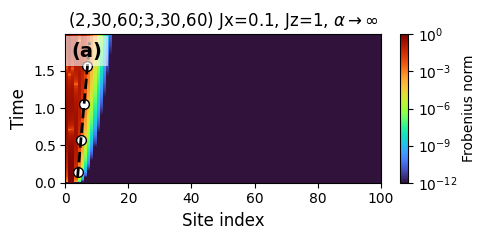

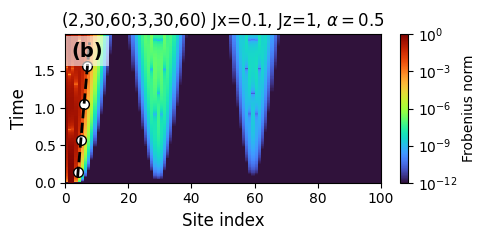

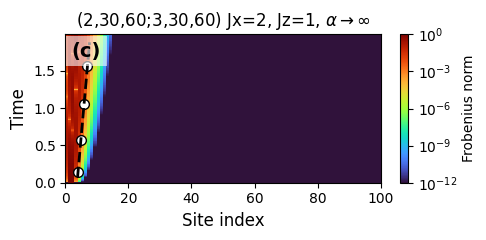

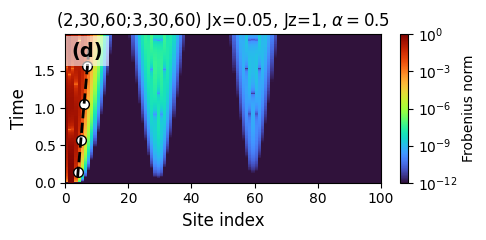

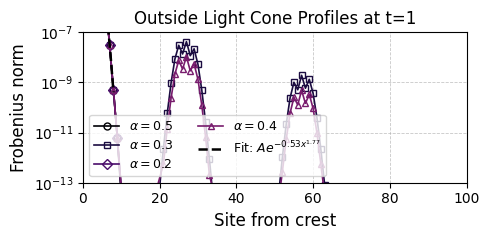

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([5,3,2,4])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N100b3varyalphanoKac{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-12, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 100)
    plt.title(fr"(2,30,60;3,30,60) Jx=0.05, Jz=1, $\alpha=0.5$", fontsize=12)
    if J == 3:
         plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha=0.5$", fontsize=12)
    if J == 2:
         plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    if J == 5:
         plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N100b3varyalphanoKac{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-13, 1e-7)
plt.xlim(0, 100)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryAlpha3.svg", dpi=600)
plt.show()



Fit slope = 0.475, intercept = -1.775


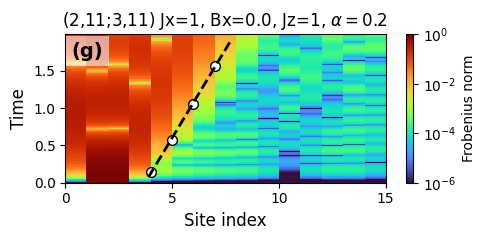

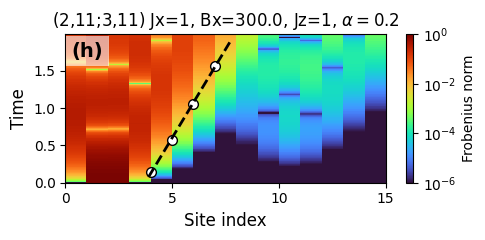

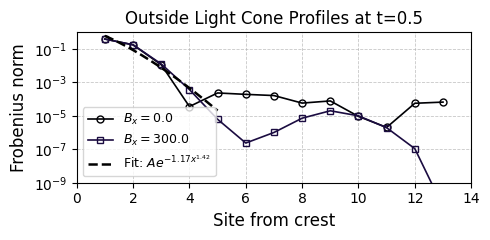

In [18]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([0,3000]) #1,100 ,5,10,15,20,25 ,5000,10000 30,300,1000, 30,300,1000, 
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 0.5

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N15Jz1a02b2Jx1BxVaried{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-6, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=7)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([0, 5, 10, 15])
    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 15)
    plt.title(fr"(2,11;3,11) Jx=1, Bx={J/10:.1f}, Jz=1, $\alpha=0.2$", fontsize=12)
    # if J == 3:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha=0.5$", fontsize=12)
    # if J == 2:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Bx2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N15Jz1a02b2Jx1BxVaried{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        continue
        # label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$B_x={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-9, 1)
plt.xlim(0, 14)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=1)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryBx3.svg", dpi=600)
plt.show()

a = 0.014348385431528372
b = -9.326607317254233


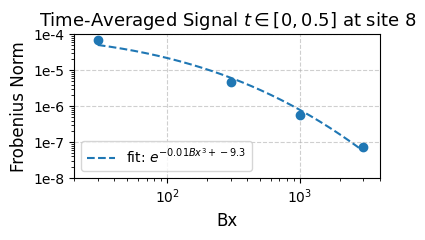

In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt

# -------------------------------------------------- 
# SETTINGS
# --------------------------------------------------
base_path = "src"
Jx_scan = np.array([30, 300, 1000, 3000])  

site_index = 8
step_size = 0.01
steps_per_unit = 1 / step_size

windows = [(0, 0.5)]
window_labels = ["0–0.5"]
colors = ["C0"]


# --------------------------------------------------
# LOAD + COMPUTE
# --------------------------------------------------
all_avg_signals = []

for (t0, t1) in windows:
    Jx_values = []
    avg_values = []

    for J in Jx_scan:
        filename = os.path.join(base_path, f"N15Jz1a02b2Jx1BxVaried{J}.txt")
        if not os.path.exists(filename):
            print(f"WARNING: Missing file {filename}")
            continue

        raw_data = load_mathematica_data(filename)
        n_steps = raw_data.shape[0]

        time_axis = np.arange(n_steps) / steps_per_unit
        col = site_index - 1

        mask = (time_axis >= t0) & (time_axis <= t1)
        values = raw_data[mask, col]
        avg_val = np.mean(values)

        Jx_values.append(J)
        avg_values.append(avg_val)

    all_avg_signals.append((np.array(Jx_values), np.array(avg_values)))


# --------------------------------------------------
# PLOT + FIT
# --------------------------------------------------
plt.figure(figsize=(4, 2.5))

for (Jx_vals, avg_vals), label, color in zip(all_avg_signals, window_labels, colors):

    x = np.log(Jx_vals)
    y = np.log(avg_vals)

    # Fit: log y = -a (log x)^2 + b
    A = np.column_stack([-x**3, np.ones_like(x)])
    params, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    a, b = params

    print("a =", a)
    print("b =", b)

    # Scatter plot of actual values
    plt.loglog(Jx_vals, avg_vals, "o", color=color)

    # smooth fit range
    Jx_fit = np.logspace(np.log10(min(Jx_vals)), np.log10(max(Jx_vals)), 300)
    x_fit = np.log(Jx_fit)

    # *** Exponential model in original (not log) space ***
    y_fit = np.exp(-a * x_fit**3 + b)

    plt.loglog(
    Jx_fit, y_fit, "--", color=color,
    label=fr"fit: $e^{{-{a:.2f} Bx^3 + {b:.1f}}}$",
    linewidth=1.5
)





plt.yticks([1e-8, 1e-7, 1e-6, 1e-5, 1e-4], ["1e-8","1e-7","1e-6","1e-5","1e-4"], fontsize=11)
plt.tick_params(axis="both", which="major", labelsize=10)

plt.xlabel("Bx", fontsize=12)
plt.ylabel("Frobenius Norm", fontsize=12)
plt.title(fr"Time-Averaged Signal $t \in [0, 0.5]$ at site {site_index}", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

plt.ylim(1e-8, 1e-4)
plt.xlim(min(Jx_scan)-10, max(Jx_scan)+1000)
plt.tight_layout()

os.makedirs("plt", exist_ok=True)
plt.savefig("plt/AvgSignal_vs_Bx.svg", dpi=600)
plt.show()


a = 0.013790019468142246
b = -9.485995022548552


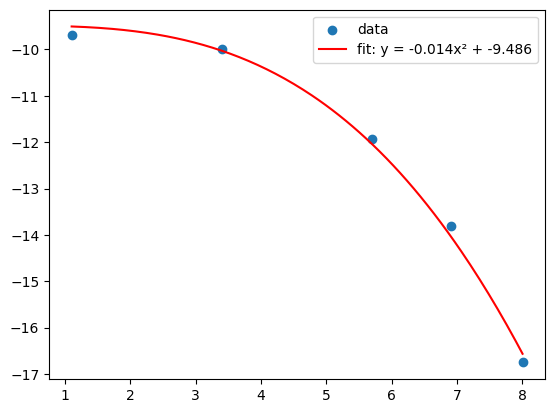

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# your log data
x = np.log(Jx_vals)
y = np.log(avg_vals)

# design matrix for y = -a x^2 + b
A = np.column_stack([ -x**3, np.ones_like(x) ])

# solve least squares
params, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
a, b = params

print("a =", a)
print("b =", b)

plt.scatter(x, y, label="data")

xx = np.linspace(min(x), max(x), 200)
yy = -a * xx**3 + b

plt.plot(xx, yy, 'r-', label=f"fit: y = -{a:.3f}x² + {b:.3f}")
plt.legend()
plt.show()


C:\Users\shrey\AppData\Local\Temp\ipykernel_24272\3489005926.py:69: RuntimeWarning: divide by zero encountered in log
  fit_vals_full = np.exp(a + b * np.log(Jx_vals))
C:\Users\shrey\AppData\Local\Temp\ipykernel_24272\3489005926.py:90: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 3.2)


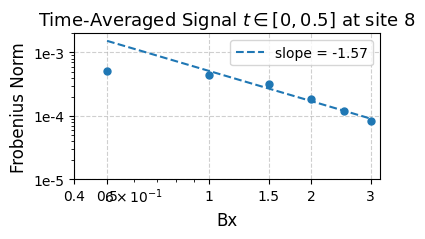

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt
# -------------------------------------------------- 
# SETTINGS
# --------------------------------------------------
base_path = "src"
Jx_scan = np.array([0,5,10,15,20,25,30])

site_index = 8      # site to extract (1-based index)
step_size = 0.01    # consistent with your old script
steps_per_unit = 1 / step_size

# Time windows to average over
windows = [
    (0, 0.5)
]

window_labels = ["0–0.5"]
colors = ["C0"]


# --------------------------------------------------
# LOAD + COMPUTE
# --------------------------------------------------
all_avg_signals = []

for (t0, t1) in windows:
    Jx_values = []
    avg_values = []

    for J in Jx_scan:
        filename = os.path.join(base_path, f"N15Jz1a02b2Jx02BxVaried{J}.txt")
        if not os.path.exists(filename):
            print(f"WARNING: Missing file {filename}")
            continue

        raw_data = load_mathematica_data(filename)
        n_steps = raw_data.shape[0]

        time_axis = np.arange(n_steps) / steps_per_unit
        col = site_index - 1

        # Time mask
        mask = (time_axis >= t0) & (time_axis <= t1)
        values = raw_data[mask, col]
        avg_val = np.mean(values)

        Jx_values.append(J)
        avg_values.append(avg_val)

    all_avg_signals.append((np.array(Jx_values), np.array(avg_values)))


# --------------------------------------------------
# PLOT + POWER-LAW FIT
# --------------------------------------------------
plt.figure(figsize=(4, 2.5))

for i, ((Jx_vals, avg_vals), label, color) in enumerate(zip(all_avg_signals, window_labels, colors)):

    # Fit parameters using Jx_vals[1:]
    xlog = np.log(Jx_vals[2:])
    ylog = np.log(avg_vals[2:])
    b, a = np.polyfit(xlog, ylog, 1)

    # ----- extend fit leftwards -----
    # Compute the fitted curve ON ALL Jx_vals
    fit_vals_full = np.exp(a + b * np.log(Jx_vals))
    Jx_plot = Jx_vals/10

    # Plot full dotted line (extends to the left now)
    plt.loglog(Jx_plot, fit_vals_full, "--", color=color, linewidth=1.5, label=f"slope = {b:.2f}")


    # Plot data
    plt.loglog(Jx_plot, avg_vals, "o", color=color, linewidth=2, markersize=5)

plt.xticks([0.4, 0.5, 1, 1.5, 2, 3], [0.4, 0.5, 1, 1.5, 2, 3], fontsize=11)
plt.yticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ["1e-6","1e-5","1e-4","1e-3","1e-2"], fontsize=11)

plt.tick_params(axis="both", which="major", labelsize=10)
plt.xlabel("Bx", fontsize=12)
plt.ylabel(f"Frobenius Norm", fontsize=12)
plt.title(fr"Time-Averaged Signal $t \in [0, 0.5]$ at site {site_index}", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

plt.ylim(1e-5, 2e-3)
plt.xlim(0, 3.2)
plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/AvgSignal_vs_Bx.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


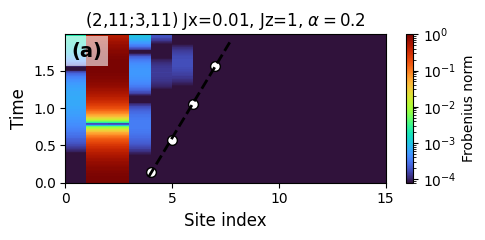

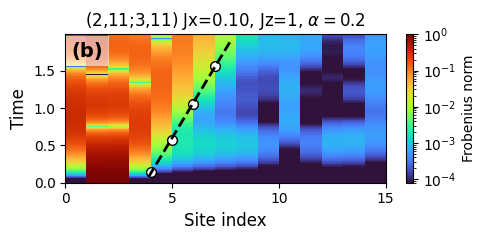

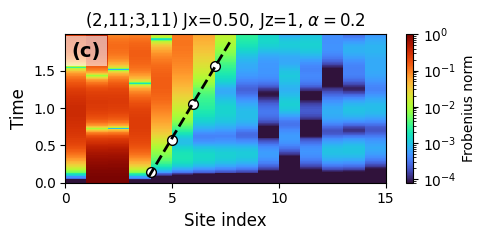

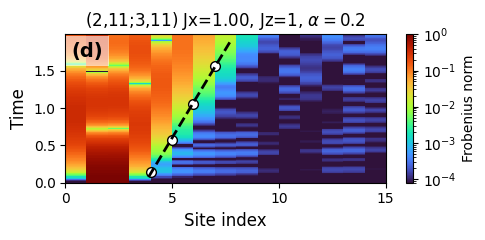

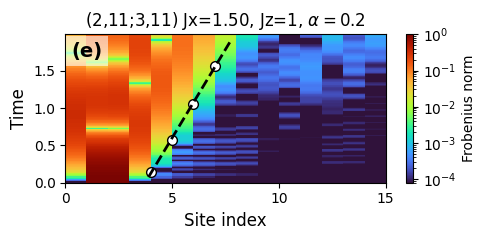

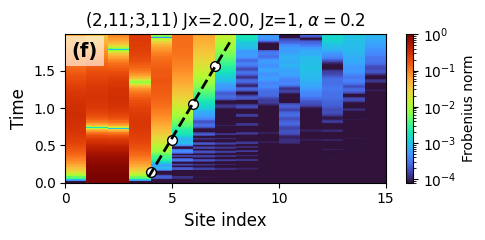

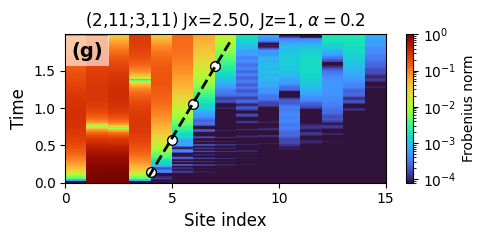

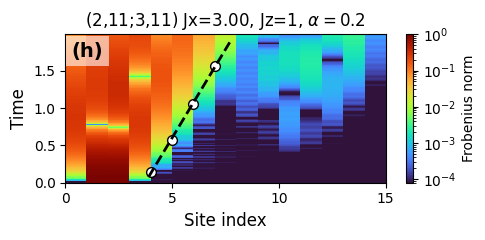

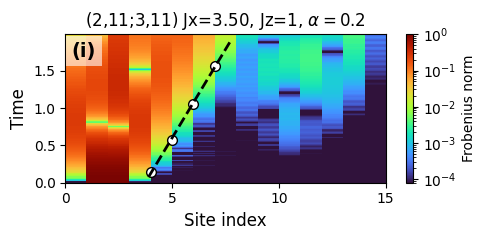

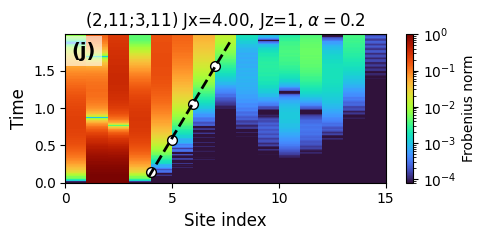

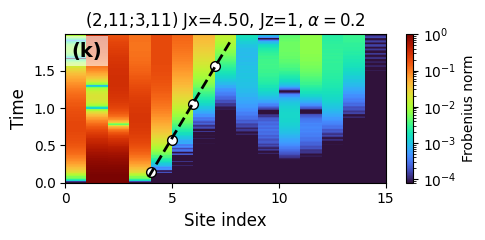

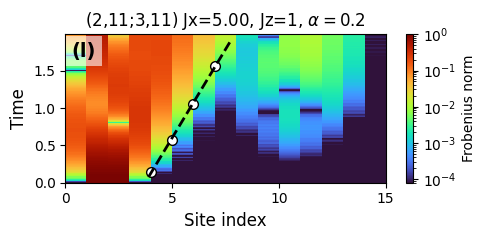

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

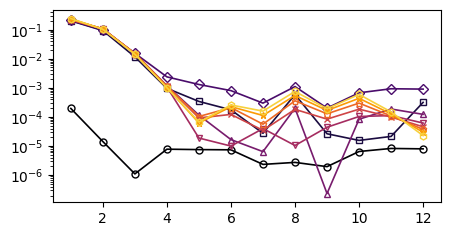

In [22]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]) #1,100
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N15a02JxVary{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=8e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([0, 5, 10, 15])
    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 15)
    plt.title(fr"(2,11;3,11) Jx={J/100:.2f}, Jz=1, $\alpha=0.2$", fontsize=12)
    # if J == 3:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha=0.5$", fontsize=12)
    # if J == 2:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Jx2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N15a02JxVary{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-13, 1e-7)
plt.xlim(0, 15)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryJx3.svg", dpi=600)
plt.show()



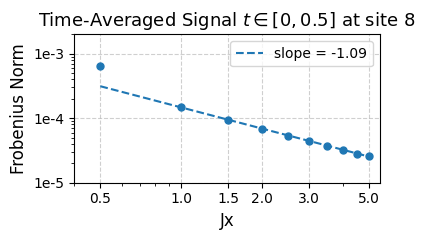

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
# -------------------------------------------------- 
# SETTINGS
# --------------------------------------------------
base_path = "src"
Jx_scan = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500])

site_index = 8      # site to extract (1-based index)
step_size = 0.01    # consistent with your old script
steps_per_unit = 1 / step_size

# Time windows to average over
windows = [
    (0, 0.5)
]

window_labels = ["0–0.5"]
colors = ["C0"]


# --------------------------------------------------
# LOAD + COMPUTE
# --------------------------------------------------
all_avg_signals = []

for (t0, t1) in windows:
    Jx_values = []
    avg_values = []

    for J in Jx_scan:
        filename = os.path.join(base_path, f"N15a02JxVary{J}.txt")
        if not os.path.exists(filename):
            print(f"WARNING: Missing file {filename}")
            continue

        raw_data = load_mathematica_data(filename)
        n_steps = raw_data.shape[0]

        time_axis = np.arange(n_steps) / steps_per_unit
        col = site_index - 1

        # Time mask
        mask = (time_axis >= t0) & (time_axis <= t1)
        values = raw_data[mask, col]
        avg_val = np.mean(values)

        Jx_values.append(J)
        avg_values.append(avg_val)

    all_avg_signals.append((np.array(Jx_values), np.array(avg_values)))


# --------------------------------------------------
# PLOT + POWER-LAW FIT
# --------------------------------------------------
plt.figure(figsize=(4, 2.5))

for i, ((Jx_vals, avg_vals), label, color) in enumerate(zip(all_avg_signals, window_labels, colors)):

    # Fit parameters using Jx_vals[1:]
    xlog = np.log(Jx_vals[1:])
    ylog = np.log(avg_vals[1:])
    b, a = np.polyfit(xlog, ylog, 1)

    # ----- extend fit leftwards -----
    # Compute the fitted curve ON ALL Jx_vals
    fit_vals_full = np.exp(a + b * np.log(Jx_vals))
    Jx_plot = Jx_vals / 100

    # Plot full dotted line (extends to the left now)
    plt.loglog(Jx_plot, fit_vals_full, "--", color=color, linewidth=1.5, label=f"slope = {b:.2f}")


    # Plot data
    plt.loglog(Jx_plot, avg_vals, "o", color=color, linewidth=2, markersize=5)

plt.xticks([0.5, 1, 1.5, 2.00, 3.00, 5.00], [.50, 1.00, 1.50, 2.00, 3.00, 5.00], fontsize=11)
plt.yticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ["1e-6","1e-5","1e-4","1e-3","1e-2"], fontsize=11)

plt.tick_params(axis="both", which="major", labelsize=10)
plt.xlabel("Jx", fontsize=12)
plt.ylabel(f"Frobenius Norm", fontsize=12)
plt.title(fr"Time-Averaged Signal $t \in [0, 0.5]$ at site {site_index}", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

plt.ylim(1e-5, 2e-3)
plt.xlim(0.4, 5.5)
plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/AvgSignal_vs_Jx.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


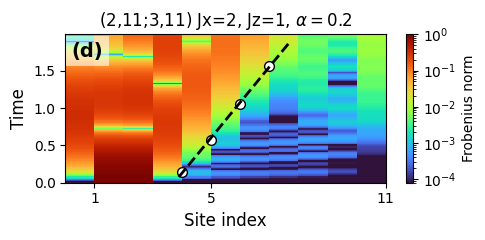

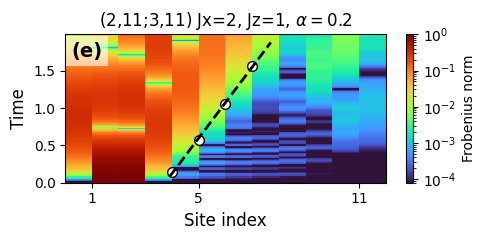

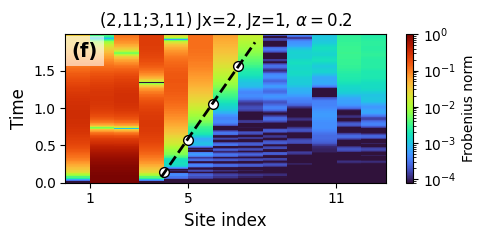

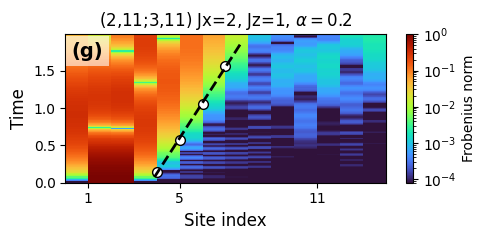

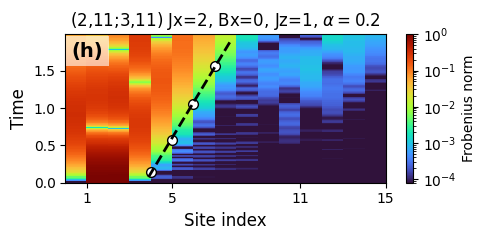

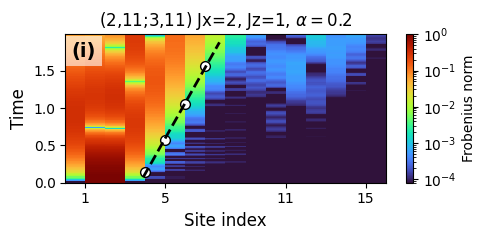

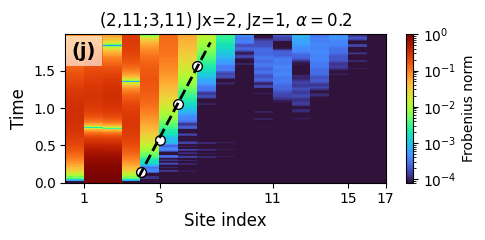

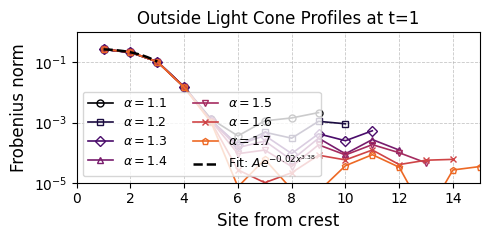

In [23]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([11,12,13,14,15,16,17]) #18,22
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"Jx2NVaried{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=8e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=4)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([1, 5, 11, 15, 17])
    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, J)
    plt.title(fr"(2,11;3,11) Jx={2}, Jz=1, $\alpha=0.2$", fontsize=12)
    if J == 15:
          plt.title(fr"(2,11;3,11) Jx=2, Bx=0, Jz=1, $\alpha=0.2$", fontsize=12)
    # if J == 2:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"Jx2NVaried{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 3
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-5, 1)
plt.xlim(0, 15)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryN3.svg", dpi=600)
plt.show()



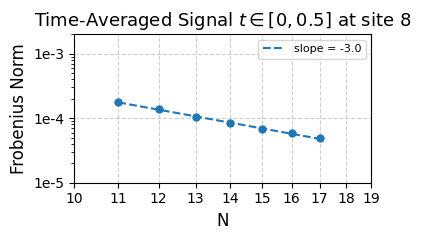

In [18]:
import numpy as np
import os
import matplotlib.pyplot as plt
# -------------------------------------------------- 
# SETTINGS
# --------------------------------------------------
base_path = "src"
Jx_scan = np.array([11,12,13,14,15,16,17]) #18,22])

site_index = 8      # site to extract (1-based index)
step_size = 0.01    # consistent with your old script
steps_per_unit = 1 / step_size

# Time windows to average over
windows = [
    (0, 0.5),
]

window_labels = ["0–0.5", "0–1", "0–1.5", "0–2"]
colors = ["C0", "C1", "C2", "C3"]


# --------------------------------------------------
# LOAD + COMPUTE
# --------------------------------------------------
all_avg_signals = []

for (t0, t1) in windows:
    Jx_values = []
    avg_values = []

    for J in Jx_scan:
        filename = os.path.join(base_path, f"Jx2NVaried{J}.txt")
        if not os.path.exists(filename):
            print(f"WARNING: Missing file {filename}")
            continue

        raw_data = load_mathematica_data(filename)
        n_steps = raw_data.shape[0]

        time_axis = np.arange(n_steps) / steps_per_unit
        col = site_index - 1

        # Time mask
        mask = (time_axis >= t0) & (time_axis <= t1)
        values = raw_data[mask, col]
        avg_val = np.mean(values)

        Jx_values.append(J)
        avg_values.append(avg_val)

    all_avg_signals.append((np.array(Jx_values), np.array(avg_values)))


# --------------------------------------------------
# PLOT + POWER-LAW FIT
# --------------------------------------------------
plt.figure(figsize=(4, 2.5))

for i, ((Jx_vals, avg_vals), label, color) in enumerate(zip(all_avg_signals, window_labels, colors)):

    # Fit parameters using Jx_vals[1:]
    xlog = np.log(Jx_vals)
    ylog = np.log(avg_vals)
    b, a = np.polyfit(xlog, ylog, 1)

    # ----- extend fit leftwards -----
    # Compute the fitted curve ON ALL Jx_vals
    fit_vals_full = np.exp(a + b * np.log(Jx_vals))
    Jx_plot = Jx_vals

    # Plot full dotted line (extends to the left now)
    plt.loglog(Jx_plot, fit_vals_full, "--", color=color, linewidth=1.5, label=fr"slope = {b:.1f}")


    # Plot data
    plt.loglog(Jx_plot, avg_vals, "o", color=color, linewidth=2, markersize=5)

plt.xticks([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,22], [10, 11, 12, 13, 14, 15, 16, 17, 18, 19,20,22], fontsize=11)
plt.yticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ["1e-6","1e-5","1e-4","1e-3","1e-2"], fontsize=12)

plt.tick_params(axis="both", which="major", labelsize=10)
plt.xlabel("N", fontsize=12)
plt.ylabel(f"Frobenius Norm", fontsize=12)
plt.title(fr"Time-Averaged Signal $t \in [0, 0.5]$ at site {site_index}", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=8, ncol=1)

plt.ylim(1e-5, 2e-3)
plt.xlim(10, 19)
plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/AvgSignal_vs_N.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


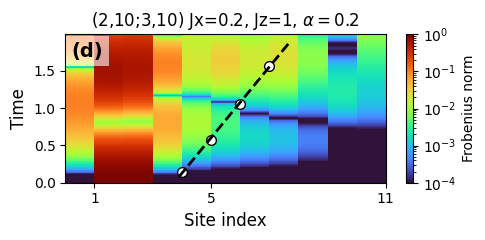

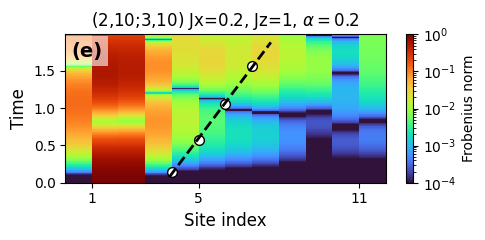

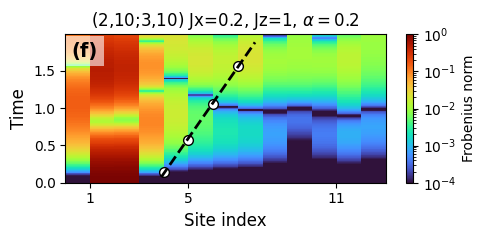

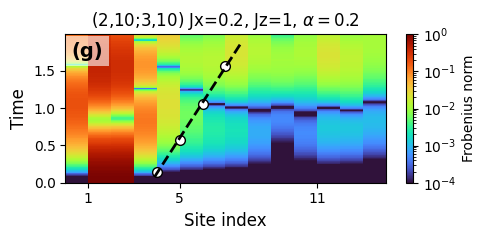

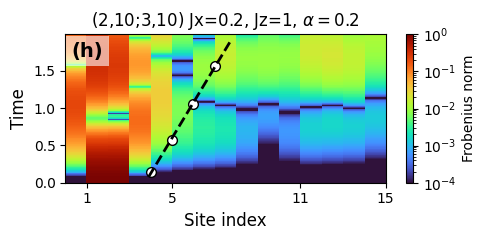

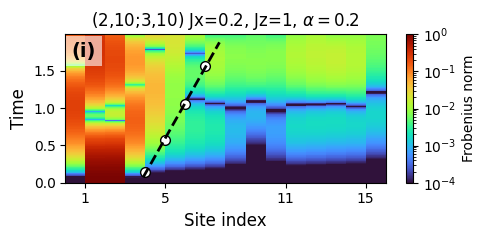

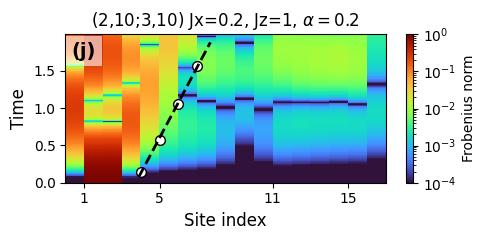

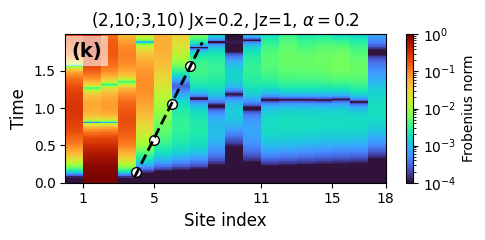

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

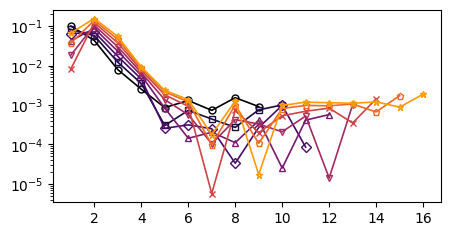

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([11,12,13,14,15,16,17,18]) #18,22
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"Jx02NVaried{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=4)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([1, 5, 11, 15, 18])
    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, J)
    plt.title(fr"(2,10;3,10) Jx={0.2}, Jz=1, $\alpha=0.2$", fontsize=12)
    # if J == 3:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha=0.5$", fontsize=12)
    # if J == 2:
    #      plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"Jx02NVaried{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 3
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-5, 1)
plt.xlim(0, 15)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryN3.svg", dpi=600)
plt.show()



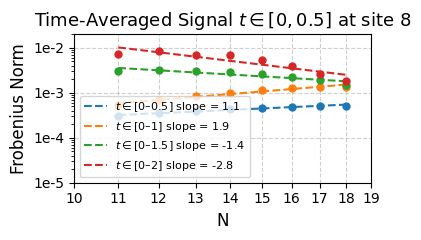

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
# -------------------------------------------------- 
# SETTINGS
# --------------------------------------------------
base_path = "src"
Jx_scan = np.array([11,12,13,14,15,16,17,18]) #18,22])

site_index = 8      # site to extract (1-based index)
step_size = 0.01    # consistent with your old script
steps_per_unit = 1 / step_size

# Time windows to average over
windows = [
    (0, 0.5),
    (0, 1),
    (0, 1.5),
    (0, 2)
]

window_labels = ["0–0.5", "0–1", "0–1.5", "0–2"]
colors = ["C0", "C1", "C2", "C3"]


# --------------------------------------------------
# LOAD + COMPUTE
# --------------------------------------------------
all_avg_signals = []

for (t0, t1) in windows:
    Jx_values = []
    avg_values = []

    for J in Jx_scan:
        filename = os.path.join(base_path, f"Jx02NVaried{J}.txt")
        if not os.path.exists(filename):
            print(f"WARNING: Missing file {filename}")
            continue

        raw_data = load_mathematica_data(filename)
        n_steps = raw_data.shape[0]

        time_axis = np.arange(n_steps) / steps_per_unit
        col = site_index - 1

        # Time mask
        mask = (time_axis >= t0) & (time_axis <= t1)
        values = raw_data[mask, col]
        avg_val = np.mean(values)

        Jx_values.append(J)
        avg_values.append(avg_val)

    all_avg_signals.append((np.array(Jx_values), np.array(avg_values)))


# --------------------------------------------------
# PLOT + POWER-LAW FIT
# --------------------------------------------------
plt.figure(figsize=(4, 2.5))

for i, ((Jx_vals, avg_vals), label, color) in enumerate(zip(all_avg_signals, window_labels, colors)):

    # Fit parameters using Jx_vals[1:]
    xlog = np.log(Jx_vals)
    ylog = np.log(avg_vals)
    b, a = np.polyfit(xlog, ylog, 1)

    # ----- extend fit leftwards -----
    # Compute the fitted curve ON ALL Jx_vals
    fit_vals_full = np.exp(a + b * np.log(Jx_vals))
    Jx_plot = Jx_vals

    # Plot full dotted line (extends to the left now)
    plt.loglog(Jx_plot, fit_vals_full, "--", color=color, linewidth=1.5, label=fr"$t \in$[{window_labels[i]}] slope = {b:.1f}")


    # Plot data
    plt.loglog(Jx_plot, avg_vals, "o", color=color, linewidth=2, markersize=5)

plt.xticks([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,22], [10, 11, 12, 13, 14, 15, 16, 17, 18, 19,20,22], fontsize=11)
plt.yticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ["1e-6","1e-5","1e-4","1e-3","1e-2"], fontsize=11)

plt.tick_params(axis="both", which="major", labelsize=10)
plt.xlabel("N", fontsize=12)
plt.ylabel(f"Frobenius Norm", fontsize=12)
plt.title(fr"Time-Averaged Signal $t \in [0, 0.5]$ at site {site_index}", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=8, ncol=1)

plt.ylim(1e-5, 2e-2)
plt.xlim(10, 19)
plt.tight_layout()
os.makedirs("plt", exist_ok=True)
plt.savefig("plt/AvgSignal_vs_N.svg", dpi=600)
plt.show()
